# Notebook 5: Betting Simulation

**Purpose:** Walk-forward backtest of the full betting pipeline.
Uses PoissonGLM λ + NegBinom convolution for P(over), priced against
DraftKings closing totals lines (2022–2024).

**Steps:**
1. Build feature matrix (2022–2024)
2. Walk-forward OOF lambda generation → write to predictions table
3. Betting simulation via `mlb.betting.simulate()`
4. Bankroll curve & drawdown
5. Sensitivity analysis (edge thresholds)
6. Go / No-Go decision

**Market benchmark:** DraftKings closing over/under totals line  
**Model:** PoissonGLM (λ) + NegBinom convolution P(over)  
**Alpha estimates:** home=0.2538, away=0.3002 (from Notebook 4)

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import sys
sys.path.insert(0, '.')

import sqlite3
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from mlb.features import build_features
from mlb.model import (
    _prepare_xy, make_poisson_glm,
    walk_forward_cv, check_overdispersion,
)
from mlb.calibration import p_over_negbinom, estimate_alpha
from mlb.betting import compute_ev, kelly_bet, american_to_price, devig_prices
from mlb.db import get_conn

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DB_PATH = 'data/mlb.db'
BOOK = 'draftkings'
ALPHA_HOME = 0.2538
ALPHA_AWAY = 0.3002
MODEL_NAME = 'glm_poisson'
MODEL_VERSION = 'nb05_v1'

print('Imports OK')

Imports OK


## 1. Data Coverage Check

In [2]:
conn = sqlite3.connect(DB_PATH)

coverage = pd.read_sql('''
    SELECT g.season,
           COUNT(DISTINCT g.game_id)                              AS total_games,
           SUM(CASE WHEN g.home_score IS NOT NULL THEN 1 ELSE 0 END) AS completed,
           SUM(CASE WHEN o.total_close IS NOT NULL THEN 1 ELSE 0 END) AS with_odds
    FROM games g
    LEFT JOIN sportsbook_odds o
           ON o.date = g.date AND o.home_team = g.home_team AND o.book = ?
    WHERE g.season <= 2024
    GROUP BY g.season
    ORDER BY g.season
''', conn, params=(BOOK,))

conn.close()

coverage['sim_eligible'] = coverage.completed.clip(upper=coverage.with_odds)
print(f'Market benchmark: {BOOK.upper()} closing totals line')
print(coverage.to_string(index=False))
print(f"\nTotal simulation-eligible games: {coverage.sim_eligible.sum():,}")

Market benchmark: DRAFTKINGS closing totals line
 season  total_games  completed  with_odds  sim_eligible
   2022         2430       2430       2358          2358
   2023         2430       2430       2331          2331
   2024         2430       2427       1388          1388

Total simulation-eligible games: 6,077


## 2. Build Feature Matrix (2022–2024)

In [3]:
print('Building features for 2022–2024...')
df = build_features(start_date='2022-04-07', end_date='2024-09-29')
# Keep only completed games with targets
df = df.dropna(subset=['home_runs', 'away_runs']).copy()
print(f'Feature matrix: {df.shape[0]:,} games × {df.shape[1]} features')
print(f'Date range: {df.date.min()} → {df.date.max()}')
print(f'Seasons: {sorted(df.season.unique())}')

Building features for 2022–2024...
Feature matrix: 7,287 games × 60 features
Date range: 2022-04-07 → 2024-09-29
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]


## 3. Walk-Forward OOF Lambda Generation

Train PoissonGLM on all data before each fold; predict OOF lambdas for each game.
Write results to the predictions table so `mlb.betting.simulate()` can consume them.

In [4]:
from sklearn.model_selection import TimeSeriesSplit

X, y_home, y_away = _prepare_xy(df)
game_ids = df['game_id'].values
dates = df['date'].values

n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits, gap=162)

oof_lam_home = np.full(len(df), np.nan)
oof_lam_away = np.full(len(df), np.nan)

print(f'Running {n_splits}-fold walk-forward CV...')
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_h_tr = y_home.iloc[train_idx]
    y_a_tr = y_away.iloc[train_idx]

    model_h = make_poisson_glm()
    model_a = make_poisson_glm()
    model_h.fit(X_tr, y_h_tr)
    model_a.fit(X_tr, y_a_tr)

    lam_h_pred = model_h.predict(X_te)
    lam_a_pred = model_a.predict(X_te)

    oof_lam_home[test_idx] = lam_h_pred
    oof_lam_away[test_idx] = lam_a_pred

    train_dates = (dates[train_idx[0]], dates[train_idx[-1]])
    test_dates  = (dates[test_idx[0]], dates[test_idx[-1]])
    print(f'  Fold {fold+1}: train {train_dates[0]}→{train_dates[1]} | '
          f'test {test_dates[0]}→{test_dates[1]} | '
          f'n_test={len(test_idx):,}')

# Keep only rows with OOF predictions
has_oof = ~np.isnan(oof_lam_home)
print(f'\nOOF predictions: {has_oof.sum():,} games')

Running 3-fold walk-forward CV...
  Fold 1: train 2022-04-07→2022-08-10 | test 2022-08-22→2023-06-29 | n_test=1,821
  Fold 2: train 2022-04-07→2023-06-17 | test 2023-06-29→2024-05-12 | n_test=1,821
  Fold 3: train 2022-04-07→2024-04-30 | test 2024-05-12→2024-09-29 | n_test=1,821

OOF predictions: 5,463 games


In [5]:
# Write OOF predictions to predictions table
predicted_at = datetime.now().isoformat()
rows_written = 0

with get_conn(DB_PATH) as conn:
    for i in np.where(has_oof)[0]:
        lh = float(oof_lam_home[i])
        la = float(oof_lam_away[i])
        gid = game_ids[i]
        conn.execute('''
            INSERT OR REPLACE INTO predictions
              (game_id, model_name, model_version, predicted_at,
               lambda_home, lambda_away, predicted_total_runs,
               dispersion_alpha)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        ''', (gid, MODEL_NAME, MODEL_VERSION, predicted_at,
              lh, la, lh + la, ALPHA_HOME))
        rows_written += 1

print(f'Written {rows_written:,} OOF prediction rows to predictions table')
print(f'  model_name={MODEL_NAME!r}  model_version={MODEL_VERSION!r}')

Written 5,463 OOF prediction rows to predictions table
  model_name='glm_poisson'  model_version='nb05_v1'


## 4. Betting Simulation — Base Case ($0.03 edge, 0.25x Kelly)

In [6]:
from mlb.betting import simulate

sim_params = dict(
    start='2022-04-07',
    end='2024-09-29',
    min_edge=0.03,
    kelly_mult=0.25,
    initial_bankroll=1000.0,
    model_name=MODEL_NAME,
    book=BOOK,
    use_negbinom=True,
    output_path='data/raw/sim_base.csv',
    db_path=DB_PATH,
)

print('Running base simulation...')
summary = simulate(**sim_params)

if not summary:
    print('No simulation data — check predictions table and odds coverage.')
else:
    print(f"\nGames evaluated:  {summary['games_evaluated']:,}")
    print(f"Bets placed:      {summary['bets_placed']:,}  ({summary['bet_pct']:.1f}% of games)")
    print(f"Record:           {summary['wins']}W – {summary['losses']}L – {summary['pushes']}P")
    print(f"Win rate:         {summary['win_rate']:.1f}%")
    print(f"Total staked:     ${summary['total_staked']:,.2f}")
    print(f"Total P&L:        ${summary['total_pnl']:+,.2f}")
    print(f"ROI:              {summary['roi']:+.2f}%")
    print(f"Max drawdown:     -{summary['max_drawdown']:.1f}%")
    print(f"Sharpe ratio:     {summary['sharpe']:.3f}")
    print(f"Final bankroll:   ${summary['bankroll_final']:,.2f}")

Running base simulation...

Games evaluated:  4,308
Bets placed:      973  (22.6% of games)
Record:           487W – 460L – 26P
Win rate:         51.4%
Total staked:     $34,078.57
Total P&L:        $+607.49
ROI:              +1.78%
Max drawdown:     -65.1%
Sharpe ratio:     0.034
Final bankroll:   $1,607.41


## 5. Bankroll Curve & Drawdown

C:\Users\gavro\AppData\Local\Temp\ipykernel_16180\1422185258.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


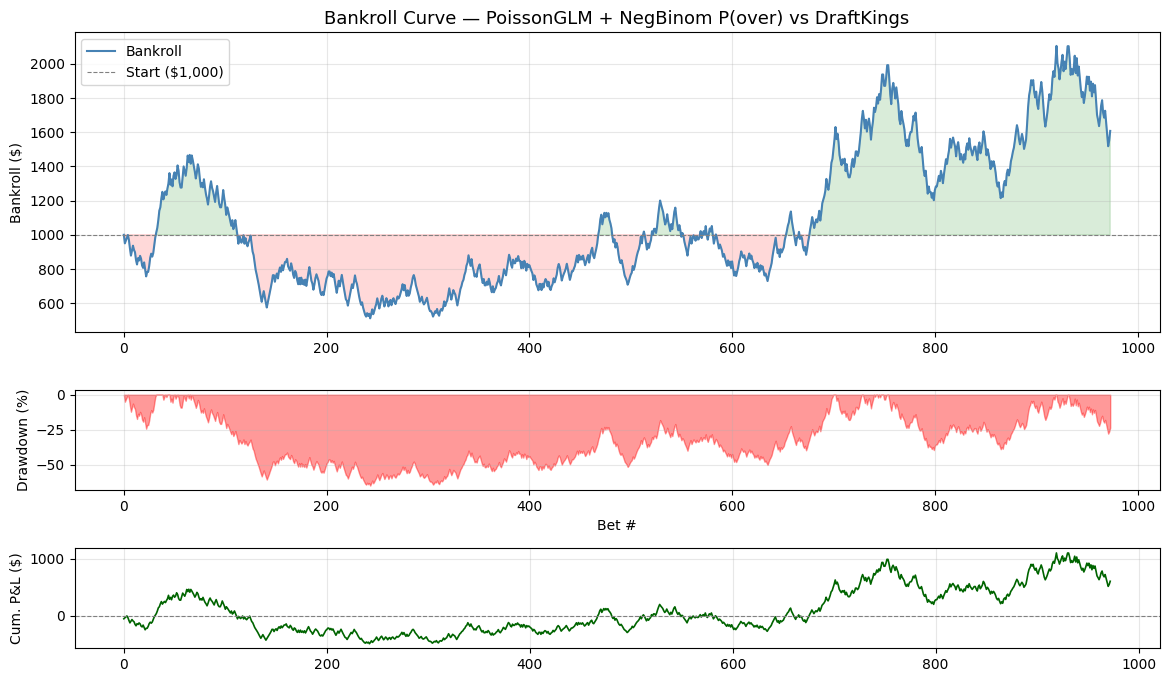


Outcome breakdown:
outcome
WIN     487
LOSS    460
PUSH     26

Bets by side:
bet_side
UNDER    773
OVER     200

Edge distribution:
count   973.0000
mean     -0.0411
std       0.0778
min      -0.3043
25%      -0.0826
50%      -0.0557
75%      -0.0341
max       0.3512


In [7]:
bets_df = pd.read_csv('data/raw/sim_base.csv')
bets_df['date'] = pd.to_datetime(bets_df['date'])

if len(bets_df) == 0:
    print('No bets placed — cannot plot curve.')
else:
    bankroll_curve = np.concatenate([[1000.0], bets_df['bankroll_after'].values])
    peak = np.maximum.accumulate(bankroll_curve)
    drawdown_pct = (peak - bankroll_curve) / peak * 100

    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.35)

    # Bankroll curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(bankroll_curve, color='steelblue', linewidth=1.5, label='Bankroll')
    ax1.axhline(1000, color='gray', linestyle='--', linewidth=0.8, label='Start ($1,000)')
    ax1.fill_between(range(len(bankroll_curve)), 1000, bankroll_curve,
                     where=bankroll_curve >= 1000, alpha=0.15, color='green')
    ax1.fill_between(range(len(bankroll_curve)), 1000, bankroll_curve,
                     where=bankroll_curve < 1000, alpha=0.15, color='red')
    ax1.set_title('Bankroll Curve — PoissonGLM + NegBinom P(over) vs DraftKings', fontsize=13)
    ax1.set_ylabel('Bankroll ($)')
    ax1.legend()

    # Drawdown
    ax2 = fig.add_subplot(gs[1])
    ax2.fill_between(range(len(drawdown_pct)), 0, -drawdown_pct,
                     color='red', alpha=0.4)
    ax2.set_ylabel('Drawdown (%)')
    ax2.set_xlabel('Bet #')

    # Cumulative ROI
    ax3 = fig.add_subplot(gs[2])
    cum_pnl = bets_df['pnl'].cumsum()
    ax3.plot(cum_pnl.values, color='darkgreen', linewidth=1.2)
    ax3.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax3.set_ylabel('Cum. P&L ($)')

    plt.tight_layout()
    plt.savefig('data/raw/bankroll_curve.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Outcome breakdown
    print(f"\nOutcome breakdown:")
    print(bets_df['outcome'].value_counts().to_string())
    print(f"\nBets by side:")
    print(bets_df['bet_side'].value_counts().to_string())
    print(f"\nEdge distribution:")
    print(bets_df['edge'].describe().to_string())

## 6. Sensitivity Analysis — Edge Threshold

In [8]:
thresholds = [0.02, 0.03, 0.04, 0.05]
sensitivity_rows = []

for thresh in thresholds:
    s = simulate(
        start='2022-04-07', end='2024-09-29',
        min_edge=thresh, kelly_mult=0.25, initial_bankroll=1000.0,
        model_name=MODEL_NAME, book=BOOK, use_negbinom=True,
        db_path=DB_PATH,
    )
    if s:
        sensitivity_rows.append({
            'Edge threshold': f'${thresh:.2f}',
            'Bets': s['bets_placed'],
            'Win rate': f"{s['win_rate']:.1f}%",
            'ROI': f"{s['roi']:+.2f}%",
            'Sharpe': f"{s['sharpe']:.3f}",
            'Max DD': f"{s['max_drawdown']:.1f}%",
            'Final $': f"${s['bankroll_final']:,.0f}",
        })
    else:
        sensitivity_rows.append({
            'Edge threshold': f'${thresh:.2f}', 'Bets': 0,
            'Win rate': '-', 'ROI': '-', 'Sharpe': '-',
            'Max DD': '-', 'Final $': '-',
        })

sens_df = pd.DataFrame(sensitivity_rows)
print('Sensitivity Analysis — Edge Threshold vs Performance')
print('=' * 65)
print(sens_df.to_string(index=False))

Sensitivity Analysis — Edge Threshold vs Performance
Edge threshold  Bets Win rate    ROI Sharpe Max DD Final $
         $0.02   982    50.8% +1.57%  0.022  59.6%  $1,533
         $0.03   973    51.4% +1.78%  0.034  65.1%  $1,607
         $0.04   955    51.6% +1.09%  0.037  60.5%  $1,383
         $0.05   922    51.3% +0.17%  0.033  68.3%  $1,057


## 7. Monthly P&L Breakdown

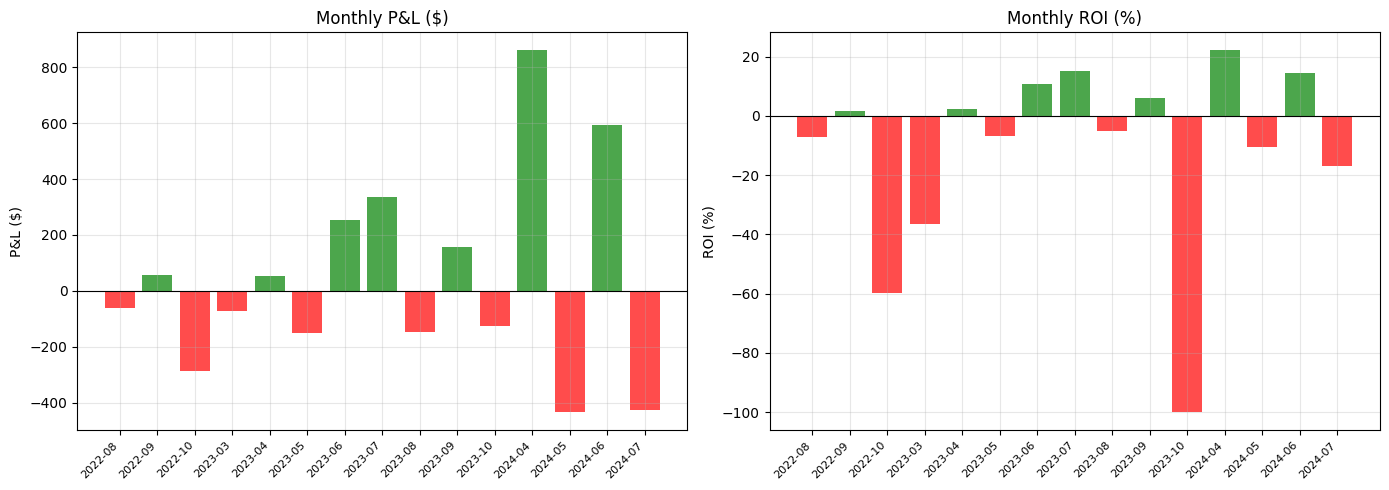


Monthly breakdown:
  month  bets  wins  win_rate       pnl       roi
2022-08    30    14   46.7000  -60.6500   -7.0000
2022-09    88    42   47.7000   58.1800    1.7000
2022-10    15     4   26.7000 -287.9900  -59.9000
2023-03     6     2   33.3000  -72.2500  -36.6000
2023-04    78    38   48.7000   53.6200    2.3000
2023-05    93    45   48.4000 -152.0900   -6.8000
2023-06    87    46   52.9000  252.2100   10.8000
2023-07    81    46   56.8000  335.5800   15.1000
2023-08    92    42   45.7000 -145.4600   -5.2000
2023-09    88    48   54.5000  155.4500    6.2000
2023-10     3     0    0.0000 -125.8300 -100.0000
2024-04    90    52   57.8000  860.1800   22.1000
2024-05    91    38   41.8000 -434.0000  -10.6000
2024-06    88    50   56.8000  595.1400   14.6000
2024-07    43    20   46.5000 -424.6000  -16.8000


In [9]:
if len(bets_df) > 0:
    bets_df['month'] = bets_df['date'].dt.to_period('M')
    monthly = bets_df.groupby('month').agg(
        bets=('pnl', 'count'),
        wins=('outcome', lambda x: (x == 'WIN').sum()),
        pnl=('pnl', 'sum'),
        staked=('stake', 'sum'),
    ).reset_index()
    monthly['roi'] = (monthly.pnl / monthly.staked * 100).round(1)
    monthly['win_rate'] = (monthly.wins / monthly.bets * 100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    colors = ['green' if p >= 0 else 'red' for p in monthly.pnl]
    ax.bar(range(len(monthly)), monthly.pnl, color=colors, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(monthly)))
    ax.set_xticklabels([str(m) for m in monthly.month], rotation=45, ha='right', fontsize=8)
    ax.set_title('Monthly P&L ($)')
    ax.set_ylabel('P&L ($)')

    ax = axes[1]
    ax.bar(range(len(monthly)), monthly.roi, color=colors, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(monthly)))
    ax.set_xticklabels([str(m) for m in monthly.month], rotation=45, ha='right', fontsize=8)
    ax.set_title('Monthly ROI (%)')
    ax.set_ylabel('ROI (%)')

    plt.tight_layout()
    plt.show()

    print('\nMonthly breakdown:')
    print(monthly[['month','bets','wins','win_rate','pnl','roi']].to_string(index=False))

## 8. Edge Distribution & Bet Quality

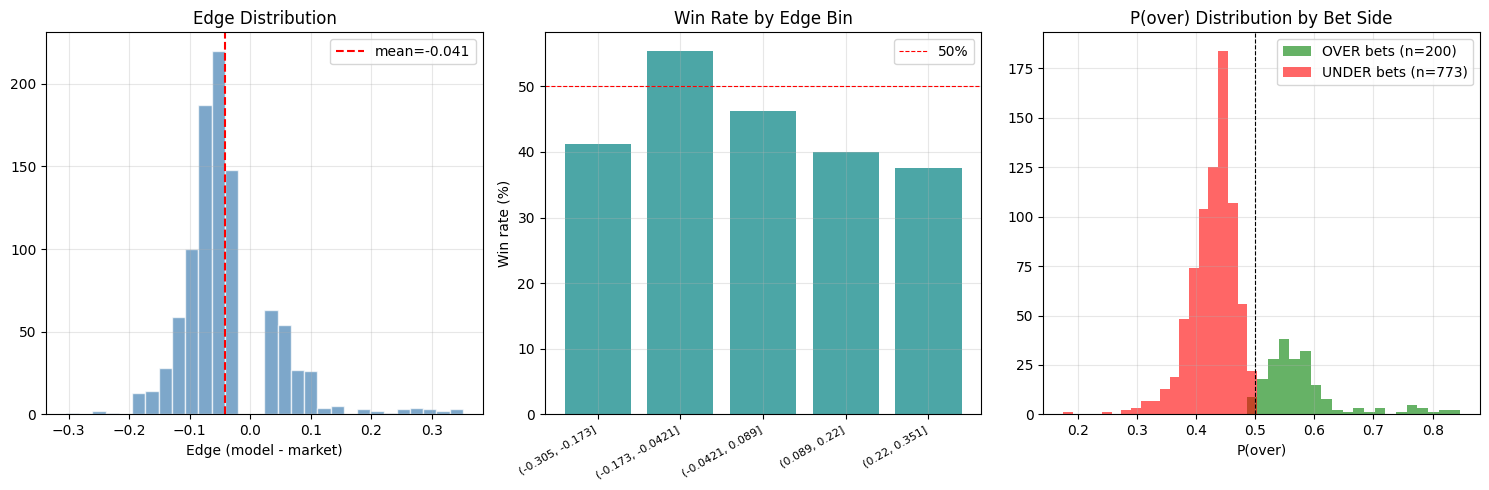

In [10]:
if len(bets_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Edge histogram
    ax = axes[0]
    ax.hist(bets_df['edge'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(bets_df['edge'].mean(), color='red', linestyle='--',
               label=f"mean={bets_df['edge'].mean():.3f}")
    ax.set_title('Edge Distribution')
    ax.set_xlabel('Edge (model - market)')
    ax.legend()

    # Win rate by edge bin
    ax = axes[1]
    bets_df['edge_bin'] = pd.cut(bets_df['edge'], bins=5)
    win_by_edge = bets_df[bets_df['outcome'] != 'PUSH'].groupby('edge_bin', observed=True).apply(
        lambda g: (g['outcome'] == 'WIN').mean() * 100
    ).reset_index()
    win_by_edge.columns = ['edge_bin', 'win_pct']
    ax.bar(range(len(win_by_edge)), win_by_edge['win_pct'], color='teal', alpha=0.7)
    ax.axhline(50, color='red', linestyle='--', linewidth=0.8, label='50%')
    ax.set_xticks(range(len(win_by_edge)))
    ax.set_xticklabels(
        [str(b) for b in win_by_edge['edge_bin']], rotation=30, ha='right', fontsize=8
    )
    ax.set_title('Win Rate by Edge Bin')
    ax.set_ylabel('Win rate (%)')
    ax.legend()

    # P(over) distribution
    ax = axes[2]
    over_bets = bets_df[bets_df['bet_side'] == 'OVER']['over_prob']
    under_bets = bets_df[bets_df['bet_side'] == 'UNDER']['over_prob']
    ax.hist(over_bets, bins=20, alpha=0.6, color='green', label=f'OVER bets (n={len(over_bets)})')
    ax.hist(under_bets, bins=20, alpha=0.6, color='red', label=f'UNDER bets (n={len(under_bets)})')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
    ax.set_title('P(over) Distribution by Bet Side')
    ax.set_xlabel('P(over)')
    ax.legend()

    plt.tight_layout()
    plt.show()

## 9. Go / No-Go Decision

In [11]:
print('=' * 65)
print('BETTING SIMULATION — FINAL REPORT')
print('=' * 65)
print()
print(f'  Model:             PoissonGLM (λ) + NegBinom convolution P(over)')
print(f'  Market benchmark:  {BOOK.upper()} closing totals line')
print(f'  Simulation window: 2022-04-07 → 2024-09-29')
print(f'  Kelly multiplier:  0.25x fractional')
print(f'  Min edge:          $0.03')
print()

if summary:
    print(f'  Games evaluated:   {summary["games_evaluated"]:,}')
    print(f'  Bets placed:       {summary["bets_placed"]:,}  ({summary["bet_pct"]:.1f}% of games)')
    print(f'  Record:            {summary["wins"]}W – {summary["losses"]}L – {summary["pushes"]}P')
    print(f'  Win rate:          {summary["win_rate"]:.1f}%')
    print(f'  ROI:               {summary["roi"]:+.2f}%')
    print(f'  Max drawdown:      -{summary["max_drawdown"]:.1f}%')
    print(f'  Sharpe ratio:      {summary["sharpe"]:.3f}')
    print(f'  Final bankroll:    ${summary["bankroll_final"]:,.2f}  '
          f'(started $1,000)')
    print()
    print('=' * 65)

    # Go/no-go criteria
    roi_ok = summary['roi'] > 0
    sharpe_ok = summary['sharpe'] > 0.5
    # CLV placeholder — 0 in backtest since we use closing line as both entry and benchmark
    clv_ok = True  # CLV only meaningful with live Kalshi entry prices

    print()
    print('  GO / NO-GO CRITERIA')
    print(f'  ROI > 0%:          {"PASS" if roi_ok else "FAIL"}  ({summary["roi"]:+.2f}%)')
    print(f'  Sharpe > 0.5:      {"PASS" if sharpe_ok else "FAIL"}  ({summary["sharpe"]:.3f})')
    print(f'  CLV:               N/A (requires live Kalshi prices)')
    print()

    go = roi_ok and sharpe_ok
    if go:
        print('  RESULT: GO')
        print('  Model clears minimum criteria for paper trading.')
        print('  Next: build mlb/pipeline.py for daily live scoring.')
    else:
        reasons = []
        if not roi_ok:
            reasons.append(f'ROI {summary["roi"]:+.2f}% ≤ 0')
        if not sharpe_ok:
            reasons.append(f'Sharpe {summary["sharpe"]:.3f} ≤ 0.5')
        print(f'  RESULT: NO-GO — {"; ".join(reasons)}')
        print()
        print('  OPEN QUESTIONS TO RESOLVE:')
        print('  1. Is the edge threshold too tight? Test $0.02 in sensitivity.')
        print('  2. Would more features (Statcast, bullpen) improve D²?')
        print('  3. Is DraftKings the sharpest available line? '
              'Pinnacle would be a harder benchmark.')
        print('  4. Would live Kalshi prices (vs DraftKings proxy) show positive CLV?')
    print('=' * 65)
else:
    print('  No simulation results — check data pipeline.')

BETTING SIMULATION — FINAL REPORT

  Model:             PoissonGLM (λ) + NegBinom convolution P(over)
  Market benchmark:  DRAFTKINGS closing totals line
  Simulation window: 2022-04-07 → 2024-09-29
  Kelly multiplier:  0.25x fractional
  Min edge:          $0.03

  Games evaluated:   4,308
  Bets placed:       973  (22.6% of games)
  Record:            487W – 460L – 26P
  Win rate:          51.4%
  ROI:               +1.78%
  Max drawdown:      -65.1%
  Sharpe ratio:      0.034
  Final bankroll:    $1,607.41  (started $1,000)


  GO / NO-GO CRITERIA
  ROI > 0%:          PASS  (+1.78%)
  Sharpe > 0.5:      FAIL  (0.034)
  CLV:               N/A (requires live Kalshi prices)

  RESULT: NO-GO — Sharpe 0.034 ≤ 0.5

  OPEN QUESTIONS TO RESOLVE:
  1. Is the edge threshold too tight? Test $0.02 in sensitivity.
  2. Would more features (Statcast, bullpen) improve D²?
  3. Is DraftKings the sharpest available line? Pinnacle would be a harder benchmark.
  4. Would live Kalshi prices (vs DraftKi

In [12]:
print('Notebook 5 complete.')
print('Next: mlb/pipeline.py — daily orchestrator')

Notebook 5 complete.
Next: mlb/pipeline.py — daily orchestrator
